Importing libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data collection and processing

In [6]:
gold_data=pd.read_csv("/content/gld_price_data.csv")

In [7]:
#print first 5 rows of the file
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [8]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [9]:
#to find number of rows and cols in the df
gold_data.shape

(2290, 6)

In [10]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [11]:
#stats measures of data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Find correlation

In [12]:
correlation = gold_data.drop('Date', axis=1).corr()

<Axes: >

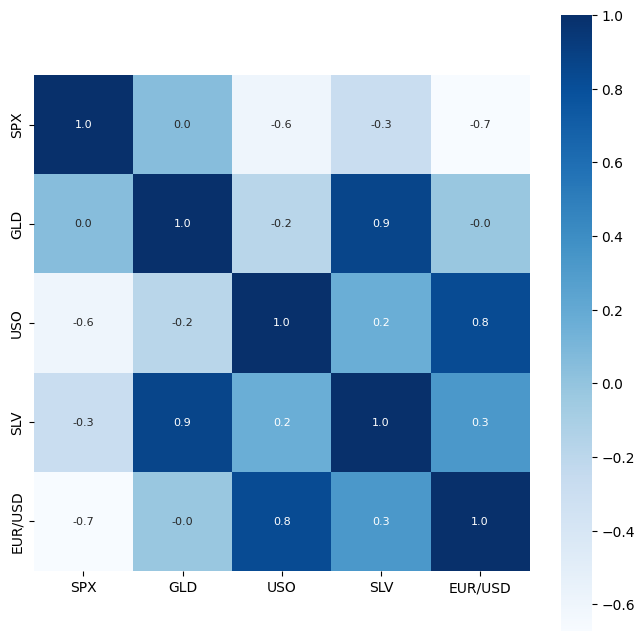

In [13]:
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [14]:
#correlation values of Gold
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_4106/2580087268.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'], color="green")


<Axes: xlabel='GLD', ylabel='Density'>

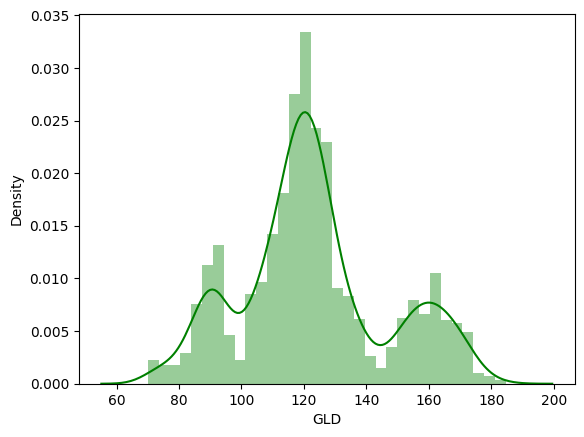

In [15]:
#check distribution of gold price
sns.distplot(gold_data['GLD'], color="green")

Now we split features and target

In [16]:
X=gold_data.drop(['Date', 'GLD'], axis=1)
Y=gold_data['GLD']

In [17]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [18]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Now we split into test data and train data

In [19]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2, random_state=2)

Training the model

In [20]:
regressor=RandomForestRegressor(n_estimators=100)

In [21]:
#training the model
regressor.fit(X_train, Y_train)

RandomForestRegressor()

Model evaluation

In [22]:
#prediction on test data

In [23]:
test_data_prediction=regressor.predict(X_test)

In [24]:
print(test_data_prediction)

[168.73269958  81.78629976 115.93230027 127.56570085 120.7431013
 154.80219736 150.71749872 126.25640023 117.43989883 125.92750105
 116.63460111 171.69950071 141.04019801 167.95219848 115.33020004
 117.49300032 137.3544033  170.20210101 159.64180306 156.98079911
 155.20270044 124.85480001 176.18949913 157.54820345 125.10230044
  93.85779984  77.9894996  120.75070024 119.05999924 167.51539961
  88.212501   125.18349976  90.98190042 117.60470016 121.11269931
 136.43960149 115.43030107 114.8252007  147.20309997 106.97430106
 104.45010236  87.336398   126.40190046 118.0781996  154.10309895
 119.56110008 108.27170009 108.11239818  93.10100073 127.14739758
  75.10040024 113.603299   121.35000029 111.24609916 118.84289878
 121.21719932 158.71610083 168.0761009  146.99629697  85.73639825
  94.29220023  86.80029868  90.80410015 119.05810073 126.39370087
 127.73020034 168.94960045 122.24189948 117.42979855  99.06700048
 168.61630219 143.26389854 132.05990246 121.26340225 121.58079929
 119.793400

In [25]:
#r square error
error_score=metrics.r2_score(Y_test, test_data_prediction)

In [26]:
print("R squared error is: ", error_score)

R squared error is:  0.9893791112961482


Since the values we got from printing "test_data_prediction" is around the 100s, an r squared error value of 0.98 is very good. This shows that our model is performing well

In [28]:
#comparing actual values and predicted values
Y_test=list(Y_test)

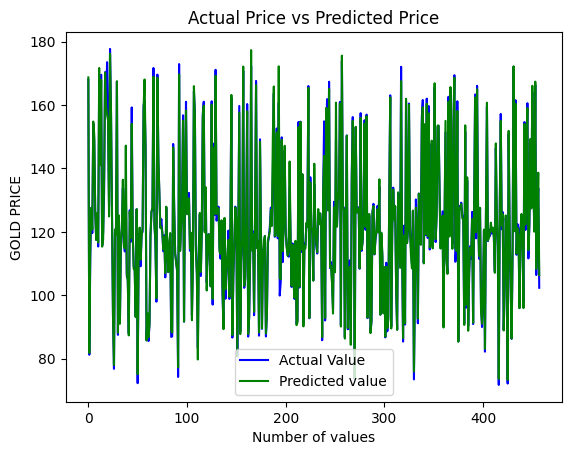

In [30]:
plt.plot(Y_test, color='blue', label='Actual Value')
plt.plot(test_data_prediction, color='green', label='Predicted value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel("Number of values")
plt.ylabel("GOLD PRICE")
plt.legend()
plt.show()

Important note: in this model, unlike my previous 2 ml models, we havent standardized the csv values. This is purely because we have used the random forest model here, which only does basic greater than or less than operations. In our previous 2 models, we used svm and logistic regression, which may consider larger numbers to be more important, thus training the model in the wrong manner. So standardization was important there, its not necessary here.